# Sesión 1: Números y funciones

### Tipos en Python vs conjuntos numéricos

##### Naturales $\mathbb N$ y enteros $\mathbb Z$

In [26]:
type(24)

int

In [27]:
type(.2)

float

In [28]:
type(10_000_000)

int

In [29]:
10_000_000

10000000

In [30]:
3000000000000000000.0

3e+18

In [31]:
n = 2e400
n

inf

In [32]:
type(n)

float

In [33]:
type(-3)

int

##### Racionales $\mathbb Q$
https://docs.python.org/3/library/fractions.html

In [47]:
from fractions import Fraction
q1=Fraction(16, -10)
q2=Fraction(12)
print(q1)
print(q2)
print(type(q1))

-8/5
12
<class 'fractions.Fraction'>


In [55]:
Fraction(12,20) == Fraction(3,5)

True

In [44]:
pi_f=Fraction('3.1415926535897932').limit_denominator(1000)
print(pi_f)

355/113


In [48]:
Fraction.from_float(0.3)

Fraction(5404319552844595, 18014398509481984)

<span style='color:red'><b>¡Ojo!</b></span> 

El método Fraction.from_float(flt) devuelve una  Fraction que representa el verdadero valor de un float. En la memoria del ordenador $0.3$ no se puede representar como una fracción binaria exacta. 

Floating-Point Arithmetic: Issues and Limitations -> https://docs.python.org/es/3/tutorial/floatingpoint.html

hay varios números decimales que comparten la misma fracción binaria más aproximada. Por ejemplo, los números 0.1, 0.10000000000000001 y 0.1000000000000000055511151231257827021181583404541015625 son todos aproximados por 3602879701896397 / 2 ** 55.

In [53]:
.1 + .1 + .1 == .3

False

In [54]:
0.10000000000000001 == 0.1000000000000000055511151231257827021181583404541015625

True

##### ¿Y los reales $\mathbb R$?

¡Alguna esperanza con los algebraicos! Por ejemplo $\sqrt 2$

In [2]:
from sympy import poly
from sympy import rem
from sympy.abc import x

In [3]:
rem(x**21 + x**12 + 8*x**3 + 1, x**2 - 2)

1040*x + 65

### Operaciones 
PEP 8 — the Style Guide for Python Code -> https://pep8.org/#other-recommendations

El formato 1+1 se puede evaluar, pero se recomienda 1 + 1

In [86]:
5.0 - 3

2.0

In [87]:
q1 * 5

Fraction(-8, 1)

In [88]:
q1 * 5.0

-8.0

In [89]:
9 / 4

2.25

In [90]:
9//4

2

In [91]:
9 % 4

1

In [92]:
5 % -3

-1

In [93]:
-5 % 3

1

In [94]:
-5 % -3

-2

$ r = x - (y * (x // y))$

### Funciones

$$ f: A \longrightarrow B$$

$$f_1(x)=\frac{1}{(x-1)}$$

In [101]:
def rational_function1(x):
    return 1 / (x - 1)

$$f_2(x)=\frac{(x-2)}{(x-2)\cdot(x-1)}$$

In [102]:
def rational_function2(x):
    return (x-2) / ((x-2) * (x - 1))

In [104]:
rational_function1(7)

0.16666666666666666

In [105]:
rational_function2(7)

0.16666666666666666

In [112]:
import numpy as np
x_left = np.linspace(-4, 0.99, 250)  # Izda de  x = 1
x_right = np.linspace(1.01, 4, 250)  # Derecha de x = 1
y_left = rational_function1(x_left)
y_right = rational_function1(x_right)

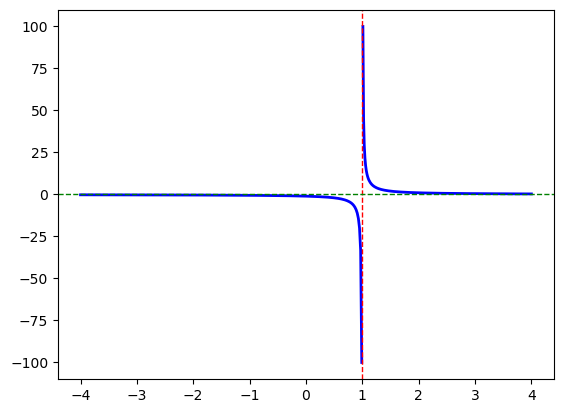

In [130]:
import matplotlib.pyplot as plt
plt.plot(x_left, y_left, color='blue', linewidth=2)
plt.plot(x_right, y_right, color='blue', linewidth=2)

plt.axvline(1, color='red', linestyle='--',
            linewidth=1, label="Vertical Asymptote (x=1)")
plt.axhline(0, color='green', linestyle='--', 
            linewidth=1, label="Horizontal Asymptote (y=0)")

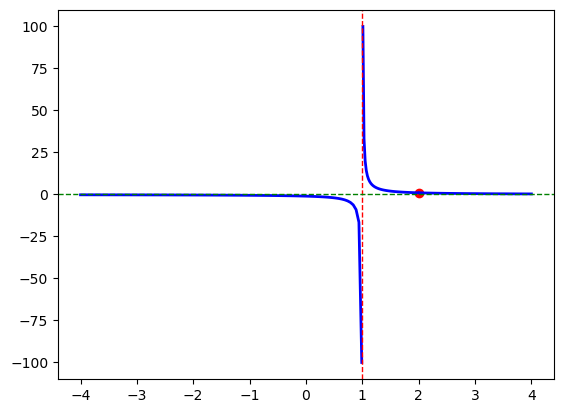

In [131]:
x2_left = np.linspace(-4, 0.99, 100)  # Izda de  x = 1
x2_mid =  np.linspace(1.01, 1.99 , 50)  # de  x = 1 a x=2
x2_right = np.linspace(2.01, 4, 100)  # Derecha de x = 2
y2_left = rational_function2(x2_left)
y2_mid = rational_function2(x2_mid)
y2_right = rational_function2(x2_right)
plt.plot(x2_left, y2_left, color='blue', linewidth=2)
plt.plot(x2_mid, y2_mid, color='blue', linewidth=2)
plt.plot(x2_right, y2_right, color='blue', linewidth=2)

plt.axvline(1, color='red', linestyle='--',
            linewidth=1, label="Vertical Asymptote (x=1)")
plt.axhline(0, color='green', linestyle='--', 
            linewidth=1, label="Horizontal Asymptote (y=0)")


plt.scatter(2, 1, color='red')

<span style='color:blue'><b>Ejercicio</b></span> 

Analiza la función "IEEE 754-style remainder" para $y=2$.  math.remainder(x, y), donde  $x$ es finito y $y$ es no nulo es 
$$x - n\cdot y,$$
con $n$ el entero más cercanoal valor de  $\frac{x}{y}$. Si la cantidad  $\frac{x}{y}$ está exactamente entre dos números enteros consecutivos, se toma $n$ como el par. Muestra que si $r$ =math.remainder(x, y) se satisface 
$$|r|\leq  0.5 \cdot |y|.$$

##### Extra

<span style='color:blue'><b>Algo extra</b></span> 

En computación no sólo importa que la función dé el resultado exacto, también importa <span style='color:red'><b>que el cálculo sea rápido</b></span>.

<span style='color:blue'><b>Ejemplo</b></span>

 Funciones polinómicas y Horner-Ruffini

In [4]:
def pol(x):
    return 2 * x**3 - 6 * x**2 + 2 * x - 1

print(f"El resultado de la evaluación es: {pol(3)}")

El resultado de la evaluación es: 5


In [5]:
def evaluar_horner(coeficientes, x):
    """
    Evalúa un polinomio usando el método de Horner.
    coeficientes: lista ordenada de mayor a menor grado [an, ..., a1, a0]
    x: valor en el que se evalúa
    """
    resultado = coeficientes[0]
    for i in range(1, len(coeficientes)):
        resultado = resultado * x + coeficientes[i]
    return resultado

# Ejemplo: P(x) = 2x^3 - 6x^2 + 2x - 1 en x = 3
# Coeficientes: [2, -6, 2, -1]
coeffs = [2, -6, 2, -1]
x_valor = 3
print(f"El resultado de la evaluación es: {evaluar_horner(coeffs, x_valor)}")


El resultado de la evaluación es: 5


<span style='color:blue'><b>Ejercicio</b></span> 

Cuenta las operaciones que se han realizado en cada implementación.

¿Puedes implementar un procedimiento similar que nos ahorre tiempo al realizar una potencia con exponente entero?